In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.datasets import make_multilabel_classification
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import (cross_val_score, KFold)
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import np_utils
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from keras.utils import np_utils
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Activation, Dense
from sklearn.model_selection import GridSearchCV
import matplotlib
import matplotlib.colors as mcolors
from pylab import rcParams
%matplotlib inline
matplotlib.style.use('ggplot')
rcParams['figure.figsize'] =20 , 16
plt.rcParams["figure.figsize"] = (20,16)
from matplotlib.pyplot import figure

In [2]:
df = pd.read_csv('bridge_info.csv')

/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (37,38,47,50,56) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [3]:
df.STATE_CODE_001.unique()

array(['VI', 'PR', 'GU', 'WY', 'WI', 'WV', 'WA', 'VA', 'VT', 'UT', 'TX',
       'TN', 'SD', 'SC', 'RI', 'PA', 'OR', 'OK', 'OH', 'ND', 'NC', 'NY',
       'NM', 'NJ', 'NH', 'NV', 'NE', 'MT', 'MO', 'MS', 'MN', 'MI', 'MA',
       'MD', 'ME', 'LA', 'KY', 'KS', 'IA', 'IN', 'IL', 'ID', 'HI', 'GA',
       'FL', 'DC', 'DE', 'CT', 'CO', 'CA', 'AR', 'AZ', 'AK', 'AL'],
      dtype=object)

In [4]:
se = df[df.STATE_CODE_001.isin(['GA' , 'AK' , 'NC' , 'SC' , 'AL' , 'MS', 'LA' , 'KY' , 'TN'])]

In [5]:
se.shape

(125356, 84)

In [6]:
se.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125356 entries, 109927 to 618453
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   STATE_CODE_001                125356 non-null  object 
 1   STRUCTURE_NUMBER_008          125356 non-null  object 
 2   DIRECTION_005E                125356 non-null  object 
 3   COUNTY_CODE_003               125216 non-null  object 
 4   FEATURES_DESC_006A            125356 non-null  object 
 5   LOCATION_009                  125356 non-null  object 
 6   MIN_VERT_CLR_010              125356 non-null  float64
 7   KILOPOINT_011                 125356 non-null  float64
 8   LAT_016                       125355 non-null  float64
 9   LONG_017                      125355 non-null  float64
 10  DETOUR_KILOS_019              125356 non-null  int64  
 11  TOLL_020                      125356 non-null  object 
 12  MAINTENANCE_021               125356 no

# Feature Selection and Data Wrangling

### Detecting features with 24 or less unique categorical values

In [7]:
objs = se.select_dtypes(include=['object']).columns
objects_df= pd.DataFrame(index = objs , columns= ['Count'])
i = 0
for obj in objs: 
    
    objects_df.iloc[i]['Count'] = (len(se[obj].unique()))
    i = i+1
    
objects_df.sort_values(by = 'Count' , inplace= True)
objects_df[objects_df.Count < 24].index

Index(['TEMP_STRUCTURE_103', 'BRIDGE_CONDITION', 'WORK_DONE_BY_075B',
       'TRAFFIC_DIRECTION_102', 'DIRECTION_005E', 'TOLL_020',
       'OPERATING_RATING_064', 'PIER_PROTECTION_111', 'FRACTURE_092A',
       'OPR_RATING_METH_063', 'MEMBRANE_TYPE_108B', 'OPEN_CLOSED_POSTED_041',
       'STATE_CODE_001', 'STRUCTURE_KIND_043A', 'DECK_STRUCTURE_TYPE_107',
       'DECK_PROTECTION_108C', 'APPR_KIND_044A', 'SURFACE_TYPE_108A',
       'UNDWATER_LOOK_SEE_092B', 'SPEC_INSPECT_092C',
       'BRIDGE_CONDITION_COMBINED', 'FUNCTIONAL_CLASS_026',
       'SCOUR_CRITICAL_113', 'DESIGN_LOAD_031', 'APPR_TYPE_044B',
       'INV_RATING_METH_065'],
      dtype='object')

### We decided to remove the features who contain more than 25 unique values to prevent the curse of dimensionalitym

In [8]:
non_features = ['STRUCTURE_TYPE_043B' ,'OPERATING_RATING_064' , 'SPEC_INSPECT_092C' , 'FRACTURE_LAST_DATE_093A' ,
               'UNDWATER_LAST_DATE_093B' , 'SPEC_LAST_DATE_093C' , 'BRIDGE_IMP_COST_094' , 'ROADWAY_IMP_COST_095' ,
               'TOTAL_IMP_COST_096' , 'YEAR_OF_IMP_097' , 'TEMP_STRUCTURE_103' , 'PIER_PROTECTION_111' , 
               'FRACTURE_092A' , 'WORK_DONE_BY_075B' , 'WORK_PROPOSED_075A' , 'IMP_LEN_MT_076', 'PIER_PROTECTION_111'
               , 'DATE_OF_INSPECT_090' , 'LONG_017' , 'YEAR_OF_FUTURE_ADT_115' , 'LAT_016' , 'MIN_VERT_CLR_010'
               ,'YEAR_ADT_030', 'YEAR_BUILT_027' , 'YEAR_RECONSTRUCTED_106' , 'TOLL_020' , 'APPR_KIND_044A' , 
               'STRUCTURE_NUMBER_008' , 'STRUCTURE_FLARED_035' , 'SCOUR_CRITICAL_COMBINED' , 'LOCATION_009',
               'FEATURES_DESC_006A' , 'DECK_GEOMETRY_EVAL_COMBINED' , 'DECK_COND_COMBINED', 'CULVERT_COND_COMBINED'
               , 'COUNTY_CODE_003' , 'CHANNEL_COND_COMBINED' , 'APPR_ROAD_EVAL_COMBINED']

features = se.columns.difference(non_features) 

In [9]:
se = se[features]

### Assessing Numerical Features

In [10]:
floats_64 = se.select_dtypes(include=['float64']).columns
ints_64 = se.select_dtypes(include=['int64']).columns

In [11]:
se[floats_64].describe()

,ADT_029,APPR_WIDTH_MT_032,DECK_AREA,DECK_WIDTH_MT_052,DEGREES_SKEW_034,FUTURE_ADT_114,INVENTORY_RATING_066,KILOPOINT_011,MAX_SPAN_LEN_MT_048,PERCENT_ADT_TRUCK_109,ROADWAY_WIDTH_MT_051,STRUCTURE_LEN_MT_049
count,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,124441.000000,125356.000000,125356.000000,114976.000000,125356.000000,125356.000000
mean,5996.283209,9.659094,655.118548,9.038154,10.839010,9042.021283,34.866496,19.090482,12.809862,8.290400,7.853004,49.851776
std,15353.375098,5.821193,3529.480085,9.777162,17.568961,23848.541504,16.511908,142.482561,13.723660,7.426295,7.373884,262.293872
min,0.000000,0.300000,4.230000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000
25%,200.000000,6.100000,89.060000,5.500000,0.000000,260.000000,24.500000,0.010000,4.600000,3.000000,4.900000,10.400000
50%,870.000000,7.900000,208.390000,8.600000,0.000000,1200.000000,32.400000,1.563000,9.100000,7.000000,7.600000,21.300000
75%,4750.000000,11.200000,587.825000,11.500000,19.000000,6600.000000,40.500000,8.624000,17.000000,11.000000,10.100000,50.600000
max,335210.000000,121.900000,372399.360000,999.900000,99.000000,520000.000000,99.900000,9999.000000,482.500000,99.000000,999.900000,38791.600000


In [12]:
se[ints_64].describe()

,APPR_SPANS_046,DETOUR_KILOS_019,INSPECT_FREQ_MONTHS_091,MAINTENANCE_021,MAIN_UNIT_SPANS_045,SERVICE_ON_042A,SERVICE_UND_042B,STATE_CODE,SUBMITTED_BY,TRAFFIC_LANES_ON_028A,TRAFFIC_LANES_UND_028B
count,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000,125356.000000
mean,0.542686,24.706667,23.608563,2.985386,3.393591,1.252593,4.600633,26.663439,27.606002,2.215554,0.466025
std,12.727358,63.494858,2.838267,9.487445,7.416043,1.017332,1.428518,15.146201,16.028130,1.237884,1.716369
min,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,2.000000,24.000000,1.000000,2.000000,1.000000,5.000000,13.000000,13.000000,2.000000,0.000000
50%,0.000000,6.000000,24.000000,1.000000,3.000000,1.000000,5.000000,28.000000,28.000000,2.000000,0.000000
75%,0.000000,14.000000,24.000000,2.000000,4.000000,1.000000,5.000000,37.000000,45.000000,2.000000,0.000000
max,2238.000000,999.000000,48.000000,79.000000,771.000000,8.000000,9.000000,47.000000,79.000000,90.000000,90.000000


### Final Feature Selection

In [13]:
features = ['BRIDGE_CONDITION', 'TRAFFIC_DIRECTION_102', 'DIRECTION_005E',
       'OPR_RATING_METH_063', 'MEMBRANE_TYPE_108B', 'OPEN_CLOSED_POSTED_041',
       'STATE_CODE_001', 'DECK_PROTECTION_108C', 'DECK_STRUCTURE_TYPE_107',
       'STRUCTURE_KIND_043A', 'UNDWATER_LOOK_SEE_092B', 'SURFACE_TYPE_108A',
       'BRIDGE_CONDITION_COMBINED', 'FUNCTIONAL_CLASS_026', 'DESIGN_LOAD_031',
       'SCOUR_CRITICAL_113', 'APPR_TYPE_044B', 'INV_RATING_METH_065' , 'ADT_029', 
       'APPR_WIDTH_MT_032', 'DECK_AREA', 'DECK_WIDTH_MT_052',
       'DEGREES_SKEW_034', 'FUTURE_ADT_114', 'INVENTORY_RATING_066',
       'KILOPOINT_011', 'MAX_SPAN_LEN_MT_048', 'PERCENT_ADT_TRUCK_109',
       'ROADWAY_WIDTH_MT_051', 'STRUCTURE_LEN_MT_049' , 'APPR_SPANS_046', 'DETOUR_KILOS_019', 
       'INSPECT_FREQ_MONTHS_091','MAINTENANCE_021', 'MAIN_UNIT_SPANS_045', 'SERVICE_ON_042A',
       'SERVICE_UND_042B', 'STATE_CODE', 'SUBMITTED_BY','TRAFFIC_LANES_ON_028A', 'TRAFFIC_LANES_UND_028B' ]

In [14]:
se = se[features]
se.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125356 entries, 109927 to 618453
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   BRIDGE_CONDITION           125356 non-null  object 
 1   TRAFFIC_DIRECTION_102      125356 non-null  object 
 2   DIRECTION_005E             125356 non-null  object 
 3   OPR_RATING_METH_063        94258 non-null   object 
 4   MEMBRANE_TYPE_108B         125356 non-null  object 
 5   OPEN_CLOSED_POSTED_041     125356 non-null  object 
 6   STATE_CODE_001             125356 non-null  object 
 7   DECK_PROTECTION_108C       125356 non-null  object 
 8   DECK_STRUCTURE_TYPE_107    125356 non-null  object 
 9   STRUCTURE_KIND_043A        125356 non-null  object 
 10  UNDWATER_LOOK_SEE_092B     125356 non-null  object 
 11  SURFACE_TYPE_108A          125356 non-null  object 
 12  BRIDGE_CONDITION_COMBINED  125356 non-null  object 
 13  FUNCTIONAL_CLASS_026    

In [15]:
se.isnull().sum()

BRIDGE_CONDITION                 0
TRAFFIC_DIRECTION_102            0
DIRECTION_005E                   0
OPR_RATING_METH_063          31098
MEMBRANE_TYPE_108B               0
OPEN_CLOSED_POSTED_041           0
STATE_CODE_001                   0
DECK_PROTECTION_108C             0
DECK_STRUCTURE_TYPE_107          0
STRUCTURE_KIND_043A              0
UNDWATER_LOOK_SEE_092B           0
SURFACE_TYPE_108A                0
BRIDGE_CONDITION_COMBINED        0
FUNCTIONAL_CLASS_026             0
DESIGN_LOAD_031                  0
SCOUR_CRITICAL_113               0
APPR_TYPE_044B                   0
INV_RATING_METH_065              0
ADT_029                          0
APPR_WIDTH_MT_032                0
DECK_AREA                        0
DECK_WIDTH_MT_052                0
DEGREES_SKEW_034                 0
FUTURE_ADT_114                   0
INVENTORY_RATING_066           915
KILOPOINT_011                    0
MAX_SPAN_LEN_MT_048              0
PERCENT_ADT_TRUCK_109        10380
ROADWAY_WIDTH_MT_051

### Removing features with Null values

In [16]:
se_prim = se[['BRIDGE_CONDITION', 'TRAFFIC_DIRECTION_102', 'DIRECTION_005E',
       'MEMBRANE_TYPE_108B', 'OPEN_CLOSED_POSTED_041',
       'STATE_CODE_001', 'DECK_PROTECTION_108C', 'DECK_STRUCTURE_TYPE_107',
       'STRUCTURE_KIND_043A', 'UNDWATER_LOOK_SEE_092B', 'SURFACE_TYPE_108A',
       'BRIDGE_CONDITION_COMBINED', 'FUNCTIONAL_CLASS_026', 'DESIGN_LOAD_031',
       'SCOUR_CRITICAL_113', 'APPR_TYPE_044B', 'INV_RATING_METH_065',
       'ADT_029', 'APPR_WIDTH_MT_032', 'DECK_AREA', 'DECK_WIDTH_MT_052',
       'DEGREES_SKEW_034', 'FUTURE_ADT_114','TRAFFIC_LANES_UND_028B',
       'KILOPOINT_011', 'MAX_SPAN_LEN_MT_048','TRAFFIC_LANES_ON_028A', 
       'ROADWAY_WIDTH_MT_051', 'STRUCTURE_LEN_MT_049', 'APPR_SPANS_046',
       'DETOUR_KILOS_019', 'INSPECT_FREQ_MONTHS_091', 'MAINTENANCE_021',
       'MAIN_UNIT_SPANS_045', 'SERVICE_ON_042A', 'SERVICE_UND_042B',
       'STATE_CODE', 'SUBMITTED_BY'] ]

se_prim.isnull().sum()

BRIDGE_CONDITION             0
TRAFFIC_DIRECTION_102        0
DIRECTION_005E               0
MEMBRANE_TYPE_108B           0
OPEN_CLOSED_POSTED_041       0
STATE_CODE_001               0
DECK_PROTECTION_108C         0
DECK_STRUCTURE_TYPE_107      0
STRUCTURE_KIND_043A          0
UNDWATER_LOOK_SEE_092B       0
SURFACE_TYPE_108A            0
BRIDGE_CONDITION_COMBINED    0
FUNCTIONAL_CLASS_026         0
DESIGN_LOAD_031              0
SCOUR_CRITICAL_113           0
APPR_TYPE_044B               0
INV_RATING_METH_065          0
ADT_029                      0
APPR_WIDTH_MT_032            0
DECK_AREA                    0
DECK_WIDTH_MT_052            0
DEGREES_SKEW_034             0
FUTURE_ADT_114               0
TRAFFIC_LANES_UND_028B       0
KILOPOINT_011                0
MAX_SPAN_LEN_MT_048          0
TRAFFIC_LANES_ON_028A        0
ROADWAY_WIDTH_MT_051         0
STRUCTURE_LEN_MT_049         0
APPR_SPANS_046               0
DETOUR_KILOS_019             0
INSPECT_FREQ_MONTHS_091      0
MAINTENA

In [17]:
se_prim.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125356 entries, 109927 to 618453
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   BRIDGE_CONDITION           125356 non-null  object 
 1   TRAFFIC_DIRECTION_102      125356 non-null  object 
 2   DIRECTION_005E             125356 non-null  object 
 3   MEMBRANE_TYPE_108B         125356 non-null  object 
 4   OPEN_CLOSED_POSTED_041     125356 non-null  object 
 5   STATE_CODE_001             125356 non-null  object 
 6   DECK_PROTECTION_108C       125356 non-null  object 
 7   DECK_STRUCTURE_TYPE_107    125356 non-null  object 
 8   STRUCTURE_KIND_043A        125356 non-null  object 
 9   UNDWATER_LOOK_SEE_092B     125356 non-null  object 
 10  SURFACE_TYPE_108A          125356 non-null  object 
 11  BRIDGE_CONDITION_COMBINED  125356 non-null  object 
 12  FUNCTIONAL_CLASS_026       125356 non-null  object 
 13  DESIGN_LOAD_031         

## According to the above insepctions following features are categorical:

In [18]:
objs = ['TRAFFIC_DIRECTION_102', 'DIRECTION_005E',
       'MEMBRANE_TYPE_108B', 'OPEN_CLOSED_POSTED_041',
       'STATE_CODE_001', 'DECK_PROTECTION_108C', 'DECK_STRUCTURE_TYPE_107',
       'STRUCTURE_KIND_043A', 'UNDWATER_LOOK_SEE_092B', 'SURFACE_TYPE_108A',
       'BRIDGE_CONDITION_COMBINED', 'FUNCTIONAL_CLASS_026', 'DESIGN_LOAD_031',
       'SCOUR_CRITICAL_113', 'APPR_TYPE_044B', 'INV_RATING_METH_065']

In [19]:
for obj in objs:
    se_prim[obj] = se_prim[obj].astype('category')

/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [20]:
se_dummies = pd.get_dummies(se_prim , columns= objs , drop_first= True )
se_dummies.reset_index(inplace=True , drop = True)
se_dummies

,BRIDGE_CONDITION,ADT_029,APPR_WIDTH_MT_032,DECK_AREA,DECK_WIDTH_MT_052,DEGREES_SKEW_034,FUTURE_ADT_114,TRAFFIC_LANES_UND_028B,KILOPOINT_011,MAX_SPAN_LEN_MT_048,...,INV_RATING_METH_065_4,INV_RATING_METH_065_5,INV_RATING_METH_065_6,INV_RATING_METH_065_7,INV_RATING_METH_065_8,INV_RATING_METH_065_A,INV_RATING_METH_065_B,INV_RATING_METH_065_C,INV_RATING_METH_065_D,INV_RATING_METH_065_F
0,F,100.0,6.7,95.14,0.0,0.0,300.0,0,0.000,4.6,...,0,1,0,0,0,0,0,0,0,0
1,G,300.0,7.3,52.56,0.0,45.0,300.0,0,0.000,3.4,...,0,1,0,0,0,0,0,0,0,0
2,F,1000.0,7.6,91.96,0.0,0.0,1000.0,0,0.000,1.2,...,0,1,0,0,0,0,0,0,0,0
3,P,500.0,10.1,192.91,0.0,0.0,500.0,0,0.000,4.0,...,0,1,0,0,0,0,0,0,0,0
4,F,300.0,9.4,390.10,0.0,0.0,300.0,0,0.000,4.4,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125351,F,5520.0,7.9,15453.36,7.8,0.0,9000.0,0,39.429,53.3,...,0,0,0,0,0,0,0,0,0,0
125352,G,430.0,11.6,687.75,10.5,99.0,600.0,0,0.000,14.0,...,0,0,0,0,0,0,0,0,0,0
125353,F,375.0,10.4,387.00,9.0,0.0,400.0,0,0.000,18.3,...,0,0,0,0,0,0,0,0,0,0
125354,G,159.0,6.5,133.28,9.8,0.0,200.0,0,1.100,12.9,...,0,0,0,0,0,0,0,0,0,0


In [21]:
se_dummies['BRIDGE_CONDITION'].value_counts()

F    59410
G    57672
P     8274
Name: BRIDGE_CONDITION, dtype: int64

In [22]:
X = se_dummies.iloc[: , 1:]
y = se_dummies['BRIDGE_CONDITION']

## Hyper-parameter Tuning of Random Forest

In [23]:
%%time
param_grid = {
    'criterion' : ['entropy' , 'gini'],
    'n_estimators': [10, 20 , 100]
}

rf = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = 2)

grid_search.fit(X, y)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
CPU times: user 2.72 s, sys: 556 ms, total: 3.28 s
Wall time: 40.3 s


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'n_estimators': [10, 20, 100]},
             verbose=2)

In [24]:
grid_search.best_params_

{'criterion': 'gini', 'n_estimators': 10}

## 5-Fold Cross Validation

In [25]:
def baseline_model():
    # create model
    model = Sequential()
    model.add(Dense(256, input_dim=180, activation='relu'))
    #model.add(Dense(128 , activation='relu'))
    #model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [26]:
i = 1
dnn_lst = []
kfold = KFold(n_splits=5, shuffle=True)
print("***** Neural Network *****")
for train_ix , test_ix in kfold.split(X): 
    
    train_x, train_y, test_x, test_y = X.iloc[train_ix], y.iloc[train_ix], X.iloc[test_ix], y.iloc[test_ix]
    dnn = KerasClassifier(build_fn=baseline_model, epochs=15, batch_size=256, verbose=0)
    dnn.fit(train_x, train_y)
    y_pred_nn = dnn.predict(test_x)
    print("***************" + "Fold", i,"***************")
    print(classification_report(test_y, y_pred_nn))
    dnn_lst.append(accuracy_score((test_y), y_pred_nn))
    print(accuracy_score((test_y), y_pred_nn))
    i = i+1 

***** Neural Network *****


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  


***************Fold 1 ***************
              precision    recall  f1-score   support

           F       0.85      0.98      0.91     11863
           G       0.97      0.88      0.92     11547
           P       1.00      0.57      0.72      1662

    accuracy                           0.90     25072
   macro avg       0.94      0.81      0.85     25072
weighted avg       0.91      0.90      0.90     25072

0.9044751116783663


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  


***************Fold 2 ***************
              precision    recall  f1-score   support

           F       0.83      1.00      0.91     11872
           G       1.00      0.80      0.89     11511
           P       0.96      0.88      0.92      1688

    accuracy                           0.90     25071
   macro avg       0.93      0.89      0.90     25071
weighted avg       0.92      0.90      0.90     25071

0.900003988672171


...

***************Fold 3 ***************
              precision    recall  f1-score   support

           F       0.86      0.96      0.91     11884
           G       0.96      0.85      0.90     11561
           P       0.88      0.86      0.87      1626

    accuracy                           0.90     25071
   macro avg       0.90      0.89      0.89     25071
weighted avg       0.91      0.90      0.90     25071

0.9019983247576882


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  


***************Fold 4 ***************
              precision    recall  f1-score   support

           F       0.79      0.99      0.88     11973
           G       0.99      0.72      0.83     11458
           P       0.86      0.93      0.89      1640

    accuracy                           0.86     25071
   macro avg       0.88      0.88      0.87     25071
weighted avg       0.89      0.86      0.86     25071

0.8619121694387938


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  


***************Fold 5 ***************
              precision    recall  f1-score   support

           F       0.95      0.93      0.94     11818
           G       0.95      0.96      0.95     11595
           P       0.85      0.92      0.89      1658

    accuracy                           0.94     25071
   macro avg       0.92      0.94      0.93     25071
weighted avg       0.94      0.94      0.94     25071

0.9432411950061824


In [27]:
i = 1
ada_lst = []
print("***** AdaBoost Classifier *****")
kfold = KFold(n_splits=5, shuffle=True)
for train_ix , test_ix in kfold.split(X): 
    
    train_x, train_y, test_x, test_y = X.iloc[train_ix], y.iloc[train_ix], X.iloc[test_ix], y.iloc[test_ix]
    ada = AdaBoostClassifier(n_estimators= 10 , random_state=42)
    ada.fit(train_x, train_y)
    y_pred = ada.predict(test_x)
    print("\n")
    print("***************" + "Fold", i,"***************")
    print(pd.crosstab(test_y, y_pred, rownames=['Actuals'], colnames=['Predictions']))
    ada_lst.append(np.round(ada.score(test_x,  test_y) , 4))
    print(np.round(ada.score(test_x,  test_y) , 4))
    i = i+1 

***** AdaBoost Classifier *****


***************Fold 1 ***************
Predictions      F      G     P
Actuals                        
F            11906      0     0
G              964  10591     0
P                0      0  1611
0.9616


***************Fold 2 ***************
Predictions      F      G     P
Actuals                        
F            11866      0     0
G                0  11525     0
P               22      0  1658
0.9991


***************Fold 3 ***************
Predictions      F      G     P
Actuals                        
F            11745      0     0
G                0  11697     0
P               16      0  1613
0.9994


***************Fold 4 ***************
Predictions      F      G     P
Actuals                        
F            11917      0     0
G                0  11469     0
P               17      0  1668
0.9993


***************Fold 5 ***************
Predictions      F      G     P
Actuals                        
F            11976      0     0
G   

In [28]:
i = 1
rfc_lst = []
print("***** Random Forest Classifier *****")
kfold = KFold(n_splits=5, shuffle=True)
for train_ix , test_ix in kfold.split(X): 
    
    train_x, train_y, test_x, test_y = X.iloc[train_ix], y.iloc[train_ix], X.iloc[test_ix], y.iloc[test_ix]
    clf = RandomForestClassifier(n_estimators= 10 , criterion='gini' , random_state=42)
    clf.fit(train_x, train_y)
    y_pred = clf.predict(test_x)
    print("\n")
    print("***************" + "Fold", i,"***************")
    print(pd.crosstab(test_y, y_pred, rownames=['Actuals'], colnames=['Predictions']))
    rfc_lst.append(np.round(clf.score(test_x,  test_y) , 4))
    print(np.round(clf.score(test_x,  test_y) , 4))
    i = i+1 

***** Random Forest Classifier *****


***************Fold 1 ***************
Predictions      F      G     P
Actuals                        
F            11807     38     2
G              118  11418     0
P               77      1  1611
0.9906


***************Fold 2 ***************
Predictions      F      G     P
Actuals                        
F            11837     30     4
G               87  11426     0
P               79      0  1608
0.992


***************Fold 3 ***************
Predictions      F      G     P
Actuals                        
F            11865     35     1
G              104  11441     0
P               78      1  1546
0.9913


***************Fold 4 ***************
Predictions      F      G     P
Actuals                        
F            11859     16     0
G               83  11507     0
P               52      0  1554
0.994


***************Fold 5 ***************
Predictions      F      G     P
Actuals                        
F            11897     19     0
G

In [29]:
i = 1
gnb_lst = []
print("***** Naive Bayes *****")
kfold = KFold(n_splits=5, shuffle=True)
for train_ix , test_ix in kfold.split(X): 
    
    train_x, train_y, test_x, test_y = X.iloc[train_ix], y.iloc[train_ix], X.iloc[test_ix], y.iloc[test_ix]
    nb = GaussianNB()
    nb.fit(train_x, train_y)
    y_pred = nb.predict(test_x)
    print("\n")
    print("***************" + "Fold", i,"***************")
    print(pd.crosstab(test_y, y_pred, rownames=['Actuals'], colnames=['Predictions']))
    gnb_lst.append(nb.score(test_x, test_y))
    print(nb.score(test_x, test_y))
    i = i+1 

***** Naive Bayes *****


***************Fold 1 ***************
Predictions     F     G     P
Actuals                      
F            3221  3457  5307
G             442  9184  1788
P             164   113  1396
0.5504546904913848


***************Fold 2 ***************
Predictions     F      G     P
Actuals                       
F            1690   5765  4320
G             304  10515   787
P             115    177  1398
0.5425790754257908


***************Fold 3 ***************
Predictions    F      G     P
Actuals                      
F            725   7196  3870
G            292  10757   583
P             66    217  1365
0.5124247138127718


***************Fold 4 ***************
Predictions     F     G     P
Actuals                      
F            5006  2853  4048
G             707  9914   934
P             192    88  1329
0.6481193410713574


***************Fold 5 ***************
Predictions     F     G     P
Actuals                      
F            3189  3587  5176
G    

In [30]:
i = 1
lg_lst = []
print("***** Logistic Regression *****")
kfold = KFold(n_splits=5, shuffle=True)
for train_ix , test_ix in kfold.split(X): 
    
    train_x, train_y, test_x, test_y = X.iloc[train_ix], y.iloc[train_ix], X.iloc[test_ix], y.iloc[test_ix]
    lg = LogisticRegression(multi_class='multinomial', solver='lbfgs')
    lg.fit(train_x, train_y)
    y_pred = lg.predict(test_x)
    print("\n")
    print("***************" + "Fold", i,"***************")
    print(pd.crosstab(test_y, y_pred, rownames=['Actuals'], colnames=['Predictions']))
    lg_lst.append(lg.score(test_x, test_y))
    print(lg.score(test_x, test_y))
    i = i+1 

***** Logistic Regression *****


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,




***************Fold 1 ***************
Predictions     F     G
Actuals                
F            7657  4237
G            5999  5506
P            1129   544
0.5250079770261646


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,




***************Fold 2 ***************
Predictions     F      G  P
Actuals                    
F            2093   9733  1
G            1326  10258  2
P             148   1510  0
0.49264089984444176


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,




***************Fold 3 ***************
Predictions     F     G  P
Actuals                   
F            6370  5559  1
G            4323  7137  1
P             969   711  0
0.5387499501415979


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,




***************Fold 4 ***************
Predictions     F     G  P
Actuals                   
F            7438  4354  2
G            5641  6038  3
P            1047   548  0
0.5375134617685773


***************Fold 5 ***************
Predictions     F     G  P
Actuals                   
F            4452  7510  3
G            2962  8473  3
P             572  1096  0
0.5155358781061784


/Users/mernegardorgoly/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


# Plotting Cross-Validation Accuracy of Each of the 5 Model

In [31]:
bar_chart = pd.DataFrame(columns = ['Fold 1' , 'Fold 2' , 'Fold 3' , 'Fold 4' , 'Fold 5'] , index = ['Logistic Regression' , 
                'Random Forest' , 'Naive Bayes' , 'Neural Netwrok' , 'AdaBoost'])

bar_chart.loc['Logistic Regression'] = lg_lst
bar_chart.loc['Random Forest'] = rfc_lst
bar_chart.loc['Random Forest'] = rfc_lst
bar_chart.loc['Naive Bayes'] = gnb_lst
bar_chart.loc['Neural Netwrok'] = dnn_lst
bar_chart.loc['AdaBoost'] = ada_lst

Text(0.5, 1.0, 'Accuracy of 5-Fold Cross-Validation')

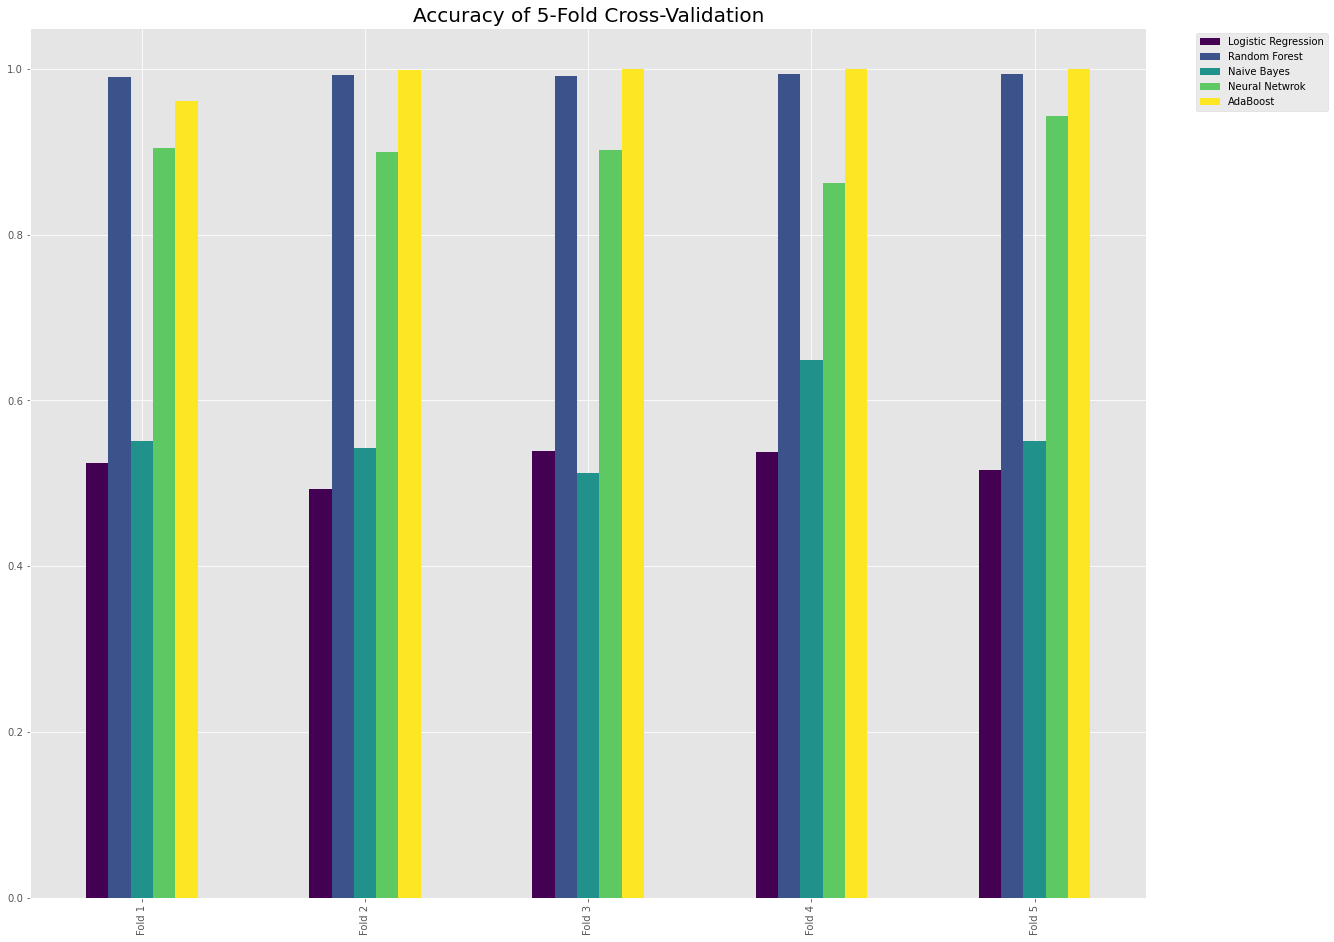

In [32]:
bar_chart.T.plot(kind = 'bar' ,colormap = 'viridis' )
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.title('Accuracy of 5-Fold Cross-Validation', fontdict={'fontsize': 20})

# Plotting the Decision Boundaies of Different Models

In [33]:
xtrain, xtest, ytrain, ytest=train_test_split(X, y, train_size=0.7, random_state=0)

In [34]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(xtrain)
X_test_sc = sc.transform (xtest)

In [35]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_sc)

X_test_pca = pca.fit_transform(X_test_sc)

In [36]:
factor_y_train = pd.factorize(ytrain)
rfc_pca = RandomForestClassifier(n_estimators = 10, criterion = 'gini', random_state = 42)
rfc_pca.fit(X_train_pca, factor_y_train[0])

RandomForestClassifier(n_estimators=10, random_state=42)

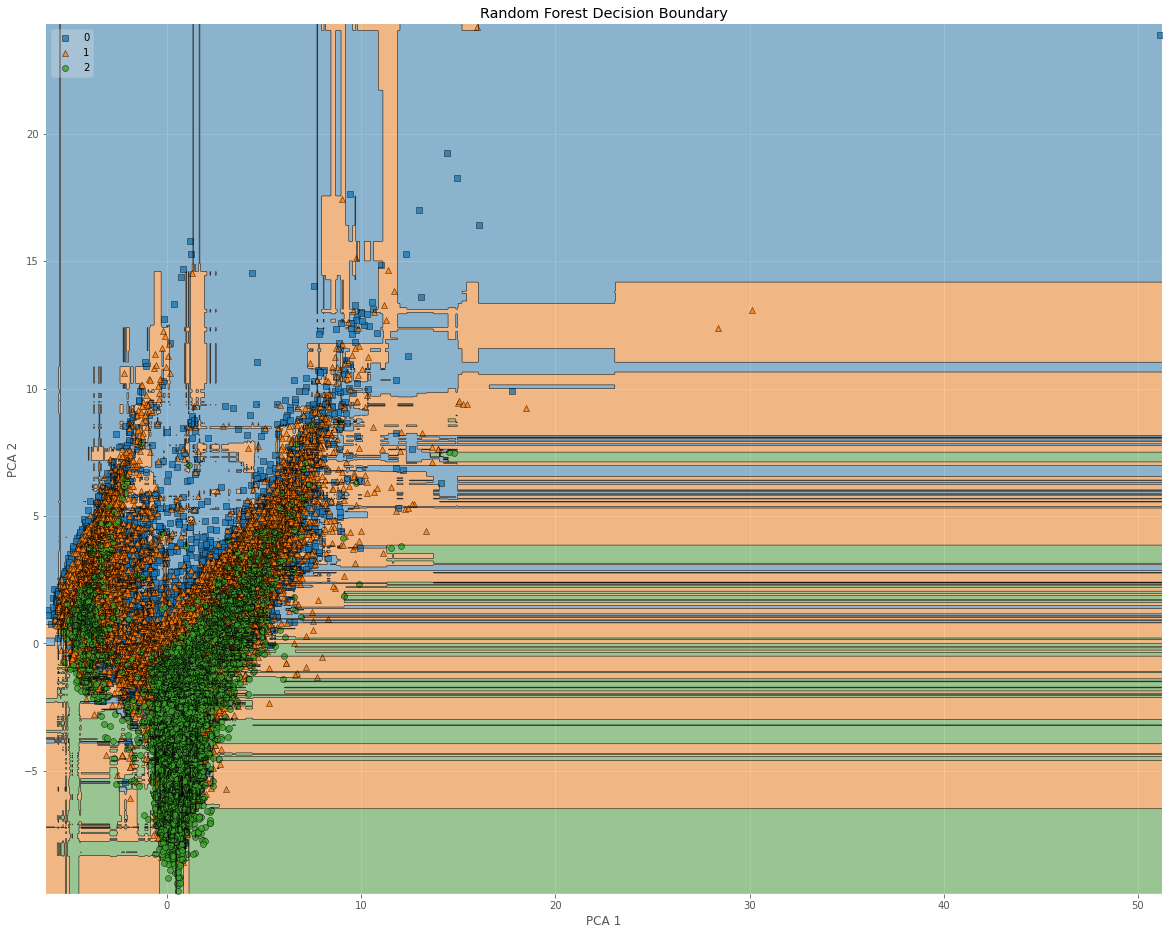

In [37]:
import matplotlib
import matplotlib.colors as mcolors
from pylab import rcParams
%matplotlib inline
matplotlib.style.use('ggplot')
rcParams['figure.figsize'] =20 , 16
plt.rcParams["figure.figsize"] = (20,16)
from matplotlib.pyplot import figure
plot_decision_regions(X_train_pca, factor_y_train[0] , clf=rfc_pca, zoom_factor=10 ,legend=2)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Random Forest Decision Boundary')
plt.show()

In [38]:
lg_pca = LogisticRegression(multi_class='multinomial', solver='lbfgs')
lg_pca.fit(X_train_pca, factor_y_train[0])

LogisticRegression(multi_class='multinomial')

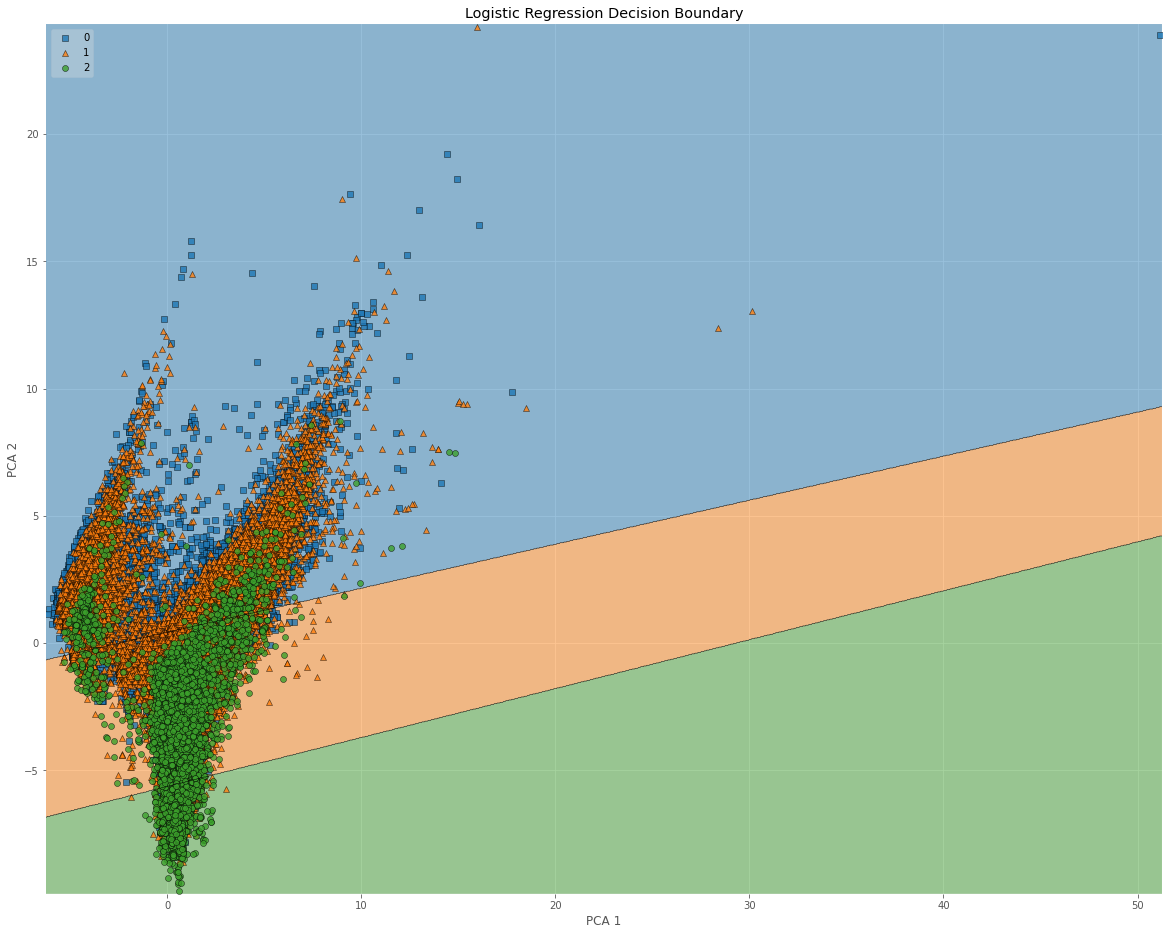

In [39]:
plot_decision_regions(X_train_pca, factor_y_train[0] , clf=lg_pca, zoom_factor=8 ,legend=2)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

In [40]:
nb_pca = GaussianNB()
nb_pca.fit(X_train_pca, factor_y_train[0])

GaussianNB()

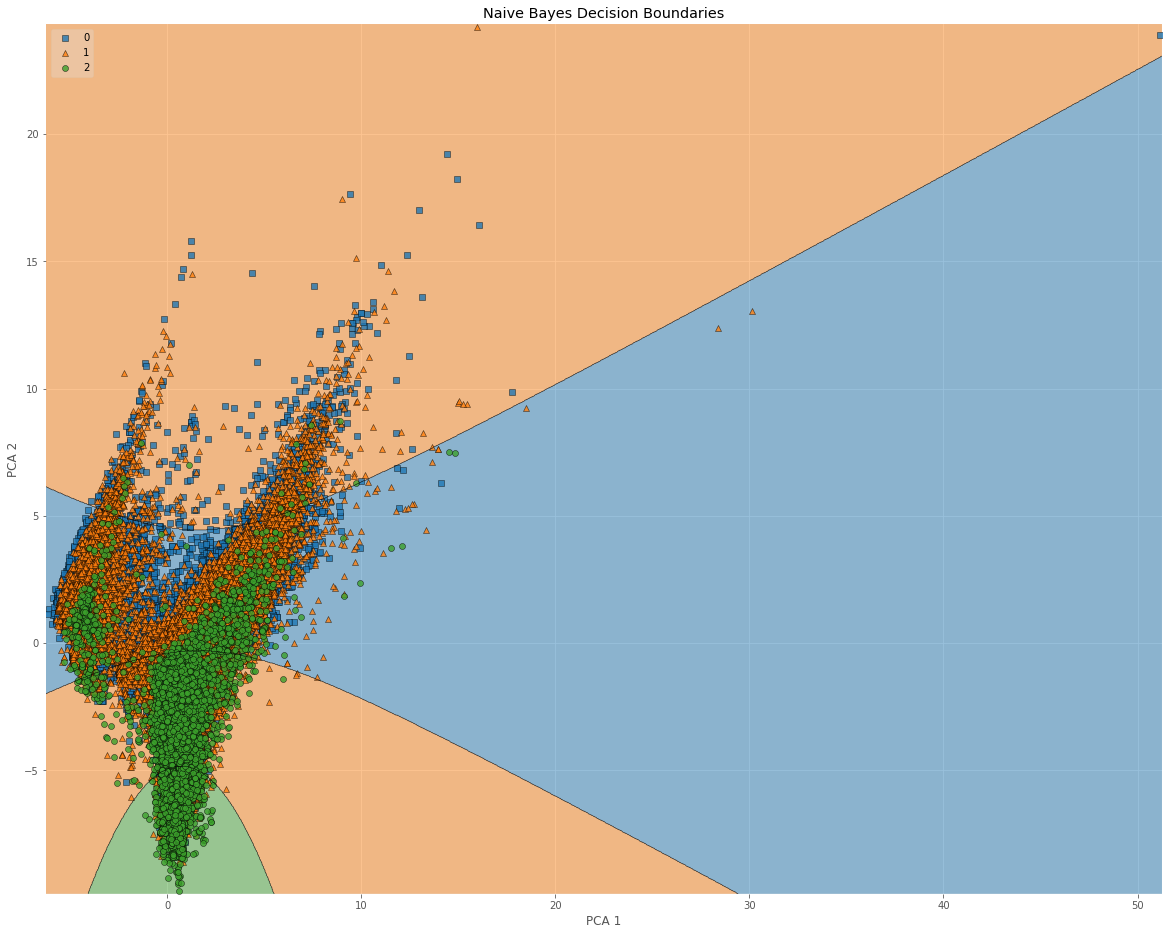

In [41]:
plot_decision_regions(X_train_pca, factor_y_train[0] , clf=nb_pca, zoom_factor=8 ,legend=2)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Naive Bayes Decision Boundaries')
plt.show()